<a href="https://colab.research.google.com/github/bshaunak13-star/Always-Happy/blob/main/SCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#Training a model on SCNN
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.neighbors import kneighbors_graph

class ChebyshevSphericalConv(nn.Module):
    """
    Strictly localized Spherical Convolution using Chebyshev Polynomials.
    """
    def __init__(self, in_channels, out_channels, K):
        super().__init__()
        self.K = K
        # The learnable filter weights (\theta_k)
        self.weight = nn.Parameter(torch.Tensor(K, in_channels, out_channels))
        self.bias = nn.Parameter(torch.Tensor(out_channels))
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x, L_scaled):
        """
        x: Input signal of shape (Batch, Nodes, In_Channels)
        L_scaled: Scaled sparse Graph Laplacian of shape (Nodes, Nodes)
        """
        B, N, C_in = x.shape

        # T_0(L)x = x
        Tx_0 = x
        out = torch.matmul(Tx_0, self.weight[0])

        if self.K > 1:
            # T_1(L)x = L * x
            # Sparse dense matrix multiplication for batched input
            # x: (B, N, C_in)
            # L_scaled: (N, N)
            # Goal: compute L_scaled @ x[b, :, :] for each b

            x_permuted = x.permute(1, 0, 2) # (N, B, C_in)
            x_flat_for_mm = x_permuted.reshape(N, B * C_in) # (N, B*C_in)

            mm_result_flat = torch.sparse.mm(L_scaled, x_flat_for_mm) # (N, B*C_in)

            Tx_1 = mm_result_flat.reshape(N, B, C_in).permute(1, 0, 2) # (B, N, C_in)
            out = out + torch.matmul(Tx_1, self.weight[1])

        # T_k(L)x = 2L * T_{k-1}(L)x - T_{k-2}(L)x
        for k in range(2, self.K):
            # Tx_1 here is T_{k-1}(L)x, which has shape (B, N, C_in)
            # We need to apply L_scaled to Tx_1, similar to how it was applied to x for Tx_1

            Tx_1_permuted = Tx_1.permute(1, 0, 2) # (N, B, C_in)
            Tx_1_flat_for_mm = Tx_1_permuted.reshape(N, B * C_in) # (N, B*C_in)

            mm_result_flat_k = torch.sparse.mm(L_scaled, Tx_1_flat_for_mm) # (N, B*C_in)

            L_times_Tx_1 = mm_result_flat_k.reshape(N, B, C_in).permute(1, 0, 2) # (B, N, C_in)

            Tx_k = 2 * L_times_Tx_1 - Tx_0
            out = out + torch.matmul(Tx_k, self.weight[k])

            # Shift states for the next recursive step
            Tx_0, Tx_1 = Tx_1, Tx_k

        return out + self.bias


class SphericalCNN(nn.Module):
    """
    A full model mapping spherical signals to a classification target.
    Updated to handle a list of L_scaled tensors for batch processing.
    """
    def __init__(self, in_features, num_classes, K=4):
        super().__init__()
        self.conv1 = ChebyshevSphericalConv(in_features, 32, K)
        self.conv2 = ChebyshevSphericalConv(32, 64, K)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x, L_scaled_list):
        # x: (Batch, Nodes, In_Channels)
        # L_scaled_list: List of B (Nodes, Nodes) sparse tensors

        batch_size = x.shape[0]
        outputs = []

        for i in range(batch_size):
            # Extract single sample and its corresponding L_scaled
            x_sample = x[i:i+1] # Keep batch dimension for conv layer
            L_scaled_sample = L_scaled_list[i]

            # First Spherical Convolution + ReLU
            x_sample = F.relu(self.conv1(x_sample, L_scaled_sample))

            # Second Spherical Convolution + ReLU
            x_sample = F.relu(self.conv2(x_sample, L_scaled_sample))

            # Global Average Pooling over all spherical nodes
            x_sample = x_sample.mean(dim=1)

            # Final classification
            outputs.append(self.fc(x_sample))

        return torch.cat(outputs, dim=0)

# ==========================================
# Prototyping Environment & Sanity Check
# ==========================================

def create_synthetic_spherical_graph(num_nodes=500, k_neighbors=6):
    """
    Generates points on a unit sphere, builds a KNN adjacency graph,
    and returns the scaled Laplacian required for Chebyshev convolutions.
    """
    # 1. Distribute points randomly on a sphere surface (Fibonacci lattice is better in practice)
    phi = np.random.uniform(0, np.pi, num_nodes)
    theta = np.random.uniform(0, 2 * np.pi, num_nodes)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    points = np.stack([x, y, z], axis=1)

    # 2. Build Adjacency Matrix using Euclidean distance in 3D (Proxy for Geodesic)
    A = kneighbors_graph(points, k_neighbors, mode='distance', include_self=False)
    A.data = np.exp(-A.data**2 / A.data.std()**2) # Convert distance to Gaussian similarity
    A = A.maximum(A.T) # Ensure symmetry

    # 3. Compute Normalized Laplacian L = I - D^{-1/2} A D^{-1/2}
    degrees = np.array(A.sum(axis=1)).flatten()
    D_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-8)
    D_inv_sqrt_mat = np.diag(D_inv_sqrt)
    Normalized_A = D_inv_sqrt_mat @ A.toarray() @ D_inv_sqrt_mat
    L = np.eye(num_nodes) - Normalized_A

    # 4. Scale Laplacian for Chebyshev polynomials: \tilde{L} = 2 * L / \lambda_{max} - I
    # (By definition, \lambda_{max} of a normalized graph Laplacian is bounded by 2)
    lambda_max = 2.0
    L_scaled = (2.0 / lambda_max) * L - np.eye(num_nodes)

    # Convert to PyTorch sparse tensor
    L_scaled = torch.tensor(L_scaled, dtype=torch.float32).to_sparse()
    return L_scaled


In [29]:
!pip install healpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 38.1 MB/s eta 0:00:00


In [ ]:
# Initialize dummy data and model
batch_size = 4
num_nodes = 500
in_channels = 3 # e.g., RGB omnidirectional image or 3D climate velocities
num_classes = 10

# Generate mesh structure and synthetic input signal
L_scaled = create_synthetic_spherical_graph(num_nodes)
signal = torch.randn(batch_size, num_nodes, in_channels)

# Initialize Model
model = SphericalCNN(in_features=in_channels, num_classes=num_classes, K=3)

print(f"Input Signal Shape: {signal.shape}")
print(f"Output Predictions Shape (before training): {model(signal, L_scaled).shape}")

Input Signal Shape: torch.Size([4, 500, 3])
Output Predictions Shape (before training): torch.Size([4, 10])


In [34]:
# MOLA MARS DATASET
import numpy as np
import rasterio
from rasterio.transform import from_origin
import healpy as hp
import torch
from scipy.interpolate import RegularGridInterpolator
import scipy.sparse as sp
import os

def create_dummy_mola_geotiff(path):
    """Generates a dummy GeoTIFF so the code doesn't crash without the PDS file."""
    print(f"Creating dummy GeoTIFF at {path} for demonstration...")
    data = np.random.randn(100, 200).astype(np.float32)
    transform = from_origin(-180, 90, 1.8, 1.8)
    with rasterio.open(path, 'w', driver='GTiff', height=data.shape[0], width=data.shape[1], count=1, dtype=data.dtype, crs='EPSG:4326', transform=transform) as dst:
        dst.write(data, 1)

def resample_mola_to_healpix(geotiff_path, nside=64):
    print("--- Step 1: Resampling MOLA Data to HEALPix Grid ---")
    if not os.path.exists(geotiff_path):
        create_dummy_mola_geotiff(geotiff_path)

    with rasterio.open(geotiff_path) as src:
        elevation_data = src.read(1)
        bounds = src.bounds
        height, width = elevation_data.shape
        lons = np.linspace(bounds.left, bounds.right, width)
        lats = np.linspace(bounds.bottom, bounds.top, height)
        if lats[0] > lats[-1]:
            lats = lats[::-1]
            elevation_data = np.flipud(elevation_data)
        print(f"Loaded GeoTIFF: {width}x{height} pixels.")

    interp = RegularGridInterpolator((lats, lons), elevation_data, method='linear', bounds_error=False, fill_value=0.0)
    num_nodes = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(num_nodes))
    hp_lats = 90.0 - np.degrees(theta)
    hp_lons = np.degrees(phi)
    query_points = np.vstack((hp_lats, hp_lons)).T
    resampled_elevation = interp(query_points)
    signal_tensor = torch.tensor(resampled_elevation, dtype=torch.float32).unsqueeze(1)
    return signal_tensor, nside

def construct_graph_laplacian(nside, r_mars=3389.5):
    print("\n--- Step 2: Constructing the Graph Laplacian ---")
    num_nodes = hp.nside2npix(nside)
    x, y, z = hp.pix2vec(nside, np.arange(num_nodes))
    structured_points = np.vstack((x*r_mars, y*r_mars, z*r_mars)).T
    row_indices, col_indices = [], []
    for i in range(num_nodes):
        # Corrected spelling: get_all_neighbours
        neighbors = hp.get_all_neighbours(nside, i)
        valid = neighbors[neighbors != -1]
        row_indices.extend([i] * len(valid))
        col_indices.extend(valid)
    A = sp.csr_matrix((np.ones(len(row_indices)), (row_indices, col_indices)), shape=(num_nodes, num_nodes))
    A = (A + A.T).sign()
    degrees = np.array(A.sum(axis=1)).flatten()
    L = sp.diags(degrees) - A
    lambda_max = sp.linalg.eigsh(L.astype(float), k=1, which='LM', return_eigenvectors=False)[0]
    L_scaled = (2.0 / lambda_max) * L - sp.eye(num_nodes)
    L_scaled_coo = L_scaled.tocoo()
    indices = torch.LongTensor(np.vstack((L_scaled_coo.row, L_scaled_coo.col)))
    L_scaled_tensor = torch.sparse_coo_tensor(indices, torch.FloatTensor(L_scaled_coo.data), L_scaled_coo.shape)
    return structured_points, L_scaled_tensor

if __name__ == "__main__":
    geotiff_path = "mola_elevation_global.tif"
    signal_tensor, nside = resample_mola_to_healpix(geotiff_path, nside=32)
    nodes_3d, L_scaled = construct_graph_laplacian(nside=nside)
    print(f"\nPipeline Ready: Signal {signal_tensor.shape}, Laplacian {L_scaled.shape}")

--- Step 1: Resampling MOLA Data to HEALPix Grid ---
Loaded GeoTIFF: 200x100 pixels.

--- Step 2: Constructing the Graph Laplacian ---

Pipeline Ready: Signal torch.Size([12288, 1]), Laplacian torch.Size([12288, 12288])


In [36]:
# File setup
from google.colab import files
import os

print("Please upload your Mars MOLA GeoTIFF file (e.g., mola_elevation_global.tif)")
uploaded = files.upload()

# Rename the uploaded file to match our pipeline expectations if necessary
for filename in uploaded.keys():
    os.rename(filename, 'mars_mola_data.tif')
    print(f'Successfully uploaded and renamed to: mars_mola_data.tif')

Please upload your Mars MOLA GeoTIFF file (e.g., mola_elevation_global.tif)


Saving PIA20327.tif to PIA20327.tif
Successfully uploaded and renamed to: mars_mola_data.tif


In [37]:
# The MOLA data model
import torch

# 1. Configuration
GEOTIFF_PATH = 'mars_mola_data.tif'
NSIDE = 32  # HEALPix resolution
IN_CHANNELS = 1 # Elevation only
NUM_CLASSES = 10 # Matches our pre-trained model structure

print("Starting Final Mars ML Pipeline...")

try:
    # 2. Preprocess Real Mars Data
    # Using the functions we defined in the previous cells
    mars_signal, nside_out = resample_mola_to_healpix(GEOTIFF_PATH, nside=NSIDE)
    mars_coords, mars_L_scaled = construct_graph_laplacian(nside=nside_out)

    # 3. Prepare Input Tensor (Add Batch Dimension: [1, Nodes, Channels])
    mars_input = mars_signal.unsqueeze(0)

    # 4. Initialize Model
    # In a production scenario, you would load your saved .pth weights here
    # model.load_state_dict(torch.load('model_weights.pth'))
    mars_model = SphericalCNN(in_features=IN_CHANNELS, num_classes=NUM_CLASSES, K=3)
    mars_model.eval()

    # 5. Run Inference
    print("\nRunning SphericalCNN Inference on Mars...")
    with torch.no_grad():
        prediction_logits = mars_model(mars_input, [mars_L_scaled])
        predicted_class = torch.argmax(prediction_logits, dim=1).item()

    print("="*30)
    print(f"RESULT: Mars Surface Classification")
    print(f"Predicted Class Category: {predicted_class}")
    print(f"Raw Logits: {prediction_logits.numpy()}")
    print("="*30)

except Exception as e:
    print(f"Error during execution: {e}")
    print("Ensure the GeoTIFF was uploaded correctly in the previous cell.")

Starting Final Mars ML Pipeline...
--- Step 1: Resampling MOLA Data to HEALPix Grid ---
Loaded GeoTIFF: 2400x2400 pixels.

--- Step 2: Constructing the Graph Laplacian ---


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



Running SphericalCNN Inference on Mars...
RESULT: Mars Surface Classification
Predicted Class Category: 5
Raw Logits: [[-0.11295515  0.10274258 -0.03280932 -0.00042541 -0.076142    0.10290593
   0.03393413 -0.0153221  -0.10255691  0.05021037]]


### Training Loop

To train the model, we need to define a loss function and an optimizer. Since this is a classification task, `CrossEntropyLoss` is a suitable choice. For the optimizer, `Adam` is a common and effective option. The training loop will then involve:

1.  **Forward Pass**: Feeding the input data through the model to get predictions.
2.  **Loss Calculation**: Comparing the predictions with the true labels to quantify the error.
3.  **Backward Pass (Backpropagation)**: Calculating gradients of the loss with respect to the model's parameters.
4.  **Optimizer Step**: Updating the model's parameters based on the calculated gradients to minimize the loss.

In [ ]:
import torch.nn as nn
import torch

# 1. Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 2. Generate Synthetic Labels (for demonstration)
# In a real scenario, these would come from your dataset
target_labels = torch.randint(0, num_classes, (batch_size,))

# 3. Training Loop
num_epochs = 20 # Train for a few epochs to see loss decrease

print("\nStarting Training Loop...")
for epoch in range(num_epochs):
    # Zero the gradients before running the backward pass
    optimizer.zero_grad()

    # Forward pass
    output = model(signal, L_scaled)

    # Calculate loss
    loss = criterion(output, target_labels)

    # Backward pass
    loss.backward()

    # Optimize the weights
    optimizer.step()

    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training Finished!")

### Training with Real Planet Data

To train the `SphericalCNN` with actual planet data, you would generally follow these steps:

1.  **Data Acquisition**: Obtain your planetary data. This could be satellite imagery, topographic maps, climate measurements, or any other data that can be associated with points on a sphere.
2.  **Node Representation**: Define the 'nodes' on your planetary sphere. This could be a fixed grid (e.g., latitude/longitude grid), or a more irregular mesh derived from specific features.
3.  **Feature Extraction (`signal`)**: For each node, extract relevant features. For example, if you have satellite images, each node might have RGB values or spectral band data. This will form your `signal` input of shape `(Batch, Nodes, In_Channels)`.
4.  **Graph Construction (`L_scaled`)**: Create a graph Laplacian (`L_scaled`) that represents the connectivity between your chosen nodes on the planet's surface. This would be similar to the `create_synthetic_spherical_graph` function, but using the actual geometry of your planet's surface (e.g., geodesic distances).
5.  **Target Labels**: Define what you are trying to predict (e.g., classification of regions, regression of a physical property). This will be your `target_labels`.
6.  **DataLoader**: If you have a large dataset, you'll want to use PyTorch's `Dataset` and `DataLoader` classes to efficiently load and batch your data during training.

Let's assume you have a dataset where each item consists of:
- A `signal` tensor: `(Nodes, In_Channels)` for a single planet or region.
- A `L_scaled` tensor: `(Nodes, Nodes)` sparse Laplacian for that specific planet/region.
- A `target_label`: An integer representing the class for that planet/region.

In [10]:
class PlanetDataset(torch.utils.data.Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # In a real scenario, you'd load these from disk or generate them
        # For this example, we'll use a simplified structure matching our synthetic data
        sample = self.data[idx]
        signal = sample['signal']
        L_scaled = sample['L_scaled']
        target = sample['target_label']
        return signal, L_scaled, target

# --- Example of creating dummy planet data for the Dataset ---
# In a real application, you would load your actual planet data here.

# Let's simulate data for a few 'planets' or 'samples'
dummy_planet_data = []
num_planets = 10 # Number of synthetic planet samples

for _ in range(num_planets):
    # Re-generate a graph Laplacian for each 'planet' to simulate variety
    current_L_scaled = create_synthetic_spherical_graph(num_nodes=num_nodes)

    # Generate a unique signal for each 'planet'
    current_signal = torch.randn(num_nodes, in_channels)

    # Assign a random target label
    current_target_label = torch.randint(0, num_classes, (1,)).item()

    dummy_planet_data.append({
        'signal': current_signal,
        'L_scaled': current_L_scaled,
        'target_label': current_target_label
    })

# Create the dataset and DataLoader
planet_dataset = PlanetDataset(dummy_planet_data)

# Custom collate_fn for handling sparse tensors in batches
def collate_fn(batch):
    signals = torch.stack([item[0] for item in batch])
    L_scaled_list = [item[1] for item in batch]
    targets = torch.tensor([item[2] for item in batch])

    # For L_scaled, we assume it's per-sample and not batched in this simple setup
    # If L_scaled was consistent across a batch, you could pass it directly.
    # For varying graphs, each sample in the batch would need its own L_scaled.
    # For simplicity, we'll take the first L_scaled in the batch as an example.
    # In a more complex scenario, you'd iterate L_scaled per sample in the forward pass.
    return signals, L_scaled_list[0], targets


# Note: If each sample has a *different* L_scaled, you will need to pass them
# one by one to the model during the forward pass, or adapt the model's forward
# method to accept a list of L_scaled and handle graph batching if possible.
# For this simplified example, we'll use a single L_scaled from the first item
# as a placeholder, implying a consistent graph structure for the batch.

# Adjust batch_size if needed, ensure it's less than or equal to num_planets
actual_batch_size = min(batch_size, num_planets)
planet_dataloader = torch.utils.data.DataLoader(
    planet_dataset,
    batch_size=actual_batch_size,
    shuffle=True,
    collate_fn=collate_fn # Use custom collate_fn
)

print(f"Number of planet samples: {len(planet_dataset)}")
print(f"Number of batches per epoch: {len(planet_dataloader)}")

# Example of one batch
for signals_batch, L_scaled_batch, targets_batch in planet_dataloader:
    print(f"Signals batch shape: {signals_batch.shape}")
    print(f"L_scaled batch shape (first item): {L_scaled_batch.shape}")
    print(f"Targets batch shape: {targets_batch.shape}")
    break


Number of planet samples: 10
Number of batches per epoch: 3
Signals batch shape: torch.Size([4, 500, 3])
L_scaled batch shape (first item): torch.Size([500, 500])
Targets batch shape: torch.Size([4])


Now, you can adapt the training loop to iterate over the `planet_dataloader`.

In [ ]:
# Re-initialize the model to ensure fresh weights for a new training run
model_planet = SphericalCNN(in_features=in_channels, num_classes=num_classes, K=3)

criterion_planet = nn.CrossEntropyLoss()
optimizer_planet = torch.optim.Adam(model_planet.parameters(), lr=0.001)

num_epochs_planet = 50 # Train for fewer epochs for this demonstration

print("\nStarting Training Loop with Planet Data...")
for epoch in range(num_epochs_planet):
    total_loss = 0.0
    for batch_idx, (signals, L_scaled_batch, targets) in enumerate(planet_dataloader):
        # Zero the gradients
        optimizer_planet.zero_grad()

        # Forward pass
        # Important: If L_scaled varies per sample in the batch, you would need to adjust
        # the model's forward pass or iterate through samples individually.
        # For this example, assuming L_scaled_batch is representative for the entire batch
        # or handling it within the model's forward if it expects a list.
        # Since create_synthetic_spherical_graph creates a sparse tensor,
        # I'm passing L_scaled_batch directly as if it's the graph for the whole batch.
        # If each sample has a *unique* graph, a more sophisticated batching or
        # an inner loop for each sample would be required.
        output = model_planet(signals, L_scaled_batch)

        # Calculate loss
        loss = criterion_planet(output, targets)

        # Backward pass
        loss.backward()

        # Optimize the weights
        optimizer_planet.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(planet_dataloader)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_planet}], Average Loss: {avg_loss:.4f}')

print("Training on Planet Data Finished!")

### Testing with Simulated Jupiter Data

To test the trained `model_planet` with data representing Jupiter, you would typically follow these steps:

1.  **Acquire Jupiter Data**: Obtain or generate the `signal` data for Jupiter (e.g., specific features at each node on its surface/atmosphere).
2.  **Generate Jupiter's Graph Laplacian**: Create the `L_scaled` tensor that represents the connectivity of the nodes on Jupiter's spherical surface. This would likely be similar to the `create_synthetic_spherical_graph` function, but parameterized for Jupiter's specific characteristics if applicable.
3.  **Prepare for Model Input**: Ensure the Jupiter data is in the correct tensor format (e.g., `(Batch=1, Nodes, In_Channels)` for `signal`).
4.  **Make Prediction**: Pass the prepared data through the trained `model_planet`.

In [12]:
# --- Simulate Jupiter's Data ---
# In a real application, you would load actual Jupiter data.

# Create a unique graph Laplacian for Jupiter
jupiter_L_scaled = create_synthetic_spherical_graph(num_nodes=num_nodes)

# Create a unique signal for Jupiter
# Assuming in_channels and num_nodes are consistent with training
jupiter_signal = torch.randn(1, num_nodes, in_channels) # Batch size of 1 for a single planet

print(f"Jupiter Signal Shape: {jupiter_signal.shape}")
print(f"Jupiter L_scaled Shape: {jupiter_L_scaled.shape}")

Jupiter Signal Shape: torch.Size([1, 500, 3])
Jupiter L_scaled Shape: torch.Size([500, 500])


In [13]:
# --- Make a prediction for Jupiter ---

# Set the model to evaluation mode
model_planet.eval()

with torch.no_grad(): # Disable gradient calculations for inference
    jupiter_output = model_planet(jupiter_signal, jupiter_L_scaled)

# Get the predicted class (assuming it's a classification task)
predicted_class = torch.argmax(jupiter_output, dim=1).item()

print(f"Model output for Jupiter: {jupiter_output}")
print(f"Predicted class for Jupiter: {predicted_class}")

# You can further interpret this prediction based on what your classes represent
# For example, if num_classes=10 represented different types of planets,
# 'predicted_class' would tell you what type the model thinks Jupiter is.

Model output for Jupiter: tensor([[ 1.6601, -3.3036,  1.4503, -3.5606,  2.0105, -3.3761, -3.7192, -4.0207,
          1.6034,  0.9448]])
Predicted class for Jupiter: 4


### Testing with Simulated Earth Data

Continuing with the pattern, for Earth data, you would:

1.  **Acquire Earth Data**: Obtain or generate the `signal` data for Earth (e.g., land cover, elevation, climate patterns at each node).
2.  **Generate Earth's Graph Laplacian**: Create the `L_scaled` tensor representing the connectivity of the nodes on Earth's spherical surface.
3.  **Prepare for Model Input**: Ensure the Earth data is in the correct tensor format.
4.  **Make Prediction**: Pass the prepared data through the trained `model_planet`.

In [14]:
# --- Simulate Earth's Data ---
# In a real application, you would load actual Earth data.

# Create a unique graph Laplacian for Earth
earth_L_scaled = create_synthetic_spherical_graph(num_nodes=num_nodes)

# Create a unique signal for Earth
# Assuming in_channels and num_nodes are consistent with training
earth_signal = torch.randn(1, num_nodes, in_channels) # Batch size of 1 for a single planet

print(f"Earth Signal Shape: {earth_signal.shape}")
print(f"Earth L_scaled Shape: {earth_L_scaled.shape}")

Earth Signal Shape: torch.Size([1, 500, 3])
Earth L_scaled Shape: torch.Size([500, 500])


In [15]:
# --- Make a prediction for Earth ---

# Set the model to evaluation mode
model_planet.eval()

with torch.no_grad(): # Disable gradient calculations for inference
    earth_output = model_planet(earth_signal, earth_L_scaled)

# Get the predicted class (assuming it's a classification task)
predicted_class_earth = torch.argmax(earth_output, dim=1).item()

print(f"Model output for Earth: {earth_output}")
print(f"Predicted class for Earth: {predicted_class_earth}")

# As before, interpret this prediction based on your defined classes.
# If num_classes=10 represented different types of planets, this would indicate
# which category the model thinks Earth falls into based on the simulated data.

Model output for Earth: tensor([[ 1.6741, -3.3385,  1.4716, -3.5948,  2.0219, -3.4090, -3.7501, -4.0542,
          1.6143,  0.9429]])
Predicted class for Earth: 4


### Replacing Synthetic Data with Real Planetary Datasets

The key to using your `SphericalCNN` model with real planetary data lies in how you prepare your input tensors: the `signal` and the `L_scaled` (graph Laplacian), along with your `target_labels`.

Here's a breakdown of the steps and considerations:

1.  **Data Acquisition and Preprocessing:**
    *   **Source**: Real planetary data can come from various sources like NASA archives (e.g., PDS - Planetary Data System), ESA, or other scientific databases. Examples include satellite imagery (optical, infrared), topographic maps (elevation data), atmospheric composition measurements, gravity field data, magnetic field data, etc.
    *   **Format**: This data often comes in formats like GeoTIFF, NetCDF, FITS, or other specialized scientific formats. You'll need libraries (e.g., `rasterio`, `netCDF4`, `astropy`) to read and process them.

2.  **Defining Nodes and Generating `signal` (`(Nodes, In_Channels)`)**:
    *   **Node Grid**: You need to define a consistent way to represent points on the planet's surface (your 'nodes'). Common approaches include:
        *   **Latitude/Longitude Grid**: A simple grid where each intersection is a node. This can be problematic near the poles.
        *   **Icosahedral Grid (e.g., HEALPix, ISEA)**: These are more uniform spherical grids that avoid the pole singularity issues of lat/lon grids and are often preferred for spherical data analysis.
        *   **Irregular Meshes**: Sometimes generated based on specific features or resolutions.
    *   **Feature Extraction (`In_Channels`)**: For each defined node, you'll extract features. If you have a satellite image, these could be RGB values. If you have elevation data, it's a single channel. If you combine elevation, temperature, and atmospheric pressure, you'd have 3 channels. You need to resample your raw data onto your chosen node grid.

    *Example:* If you use a HEALPix grid, you'd define the resolution (e.g., `nside`) to get your `num_nodes`, then extract corresponding data values for each pixel/node.

In [16]:
# Conceptual example for signal generation (requires specific libraries and data)
# This is illustrative, actual implementation depends heavily on data source and grid choice.

# Assuming you have a function to get data for a specific planet (e.g., 'earth_data.tif')
def load_and_process_planet_data(planet_name, num_nodes, in_channels):
    # Placeholder for actual data loading and resampling
    # In reality, this would involve reading actual image/scientific data
    # and mapping it to the `num_nodes` spherical grid.

    # For now, we'll just return a random signal to match the shape
    # but imagine this is derived from actual sensor readings or climate models.
    signal = torch.randn(num_nodes, in_channels)
    print(f"Loaded and processed signal for {planet_name} with shape: {signal.shape}")
    return signal

# Example usage:
# real_earth_signal = load_and_process_planet_data('Earth', num_nodes, in_channels)
# real_jupiter_signal = load_and_process_planet_data('Jupiter', num_nodes, in_channels)


3.  **Constructing the Graph Laplacian (`L_scaled`)**:
    *   The `create_synthetic_spherical_graph` function currently uses random points and `kneighbors_graph`. For real data, your `L_scaled` should reflect the *actual connectivity* or spatial relationships of your chosen nodes on the planet's surface.
    *   **For Gridded Data (e.g., HEALPix, lat/lon)**: Connectivity can be defined by adjacent grid cells. For example, each node could be connected to its 4 or 8 immediate neighbors on the grid. Libraries like `healpy` (for HEALPix) might have functions to help define adjacency.
    *   **For Irregular Meshes**: The graph Laplacian is derived from the mesh structure itself (vertices and edges).
    *   **Weights**: The edge weights in your adjacency matrix (before computing Laplacian) could be uniform, or weighted by geodesic distance, feature similarity, or other physical properties.

    The `L_scaled` tensor should still be a `(Nodes, Nodes)` sparse matrix, typically normalized as `2 * L / lambda_max - I` for Chebyshev convolutions. The `create_synthetic_spherical_graph` function's logic for calculating `D_inv_sqrt_mat`, `Normalized_A`, and `L` would be similar, but the initial adjacency matrix `A` would come from your real connectivity.

In [17]:
# Conceptual example for L_scaled generation for real data
# This assumes a specific grid type (e.g., a structured HEALPix grid).

def create_real_planet_L_scaled(num_nodes, k_neighbors_for_graph=6):
    # In a real scenario, you would not use random points.
    # Instead, you'd use the actual coordinates of your chosen spherical nodes
    # (e.g., HEALPix pixel centers or latitude/longitude points).

    # For illustration, let's assume you have a way to get *structured* points
    # For instance, from a HEALPix grid, you'd get the actual 3D coordinates
    # of the pixel centers.
    # dummy_structured_points = get_healpix_coords(nside_resolution)

    # For this example, we'll keep the `kneighbors_graph` part similar
    # but conceptually, the 'points' would be from a defined grid.
    phi = np.random.uniform(0, np.pi, num_nodes)
    theta = np.random.uniform(0, 2 * np.pi, num_nodes)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    structured_points = np.stack([x, y, z], axis=1)

    A = kneighbors_graph(structured_points, k_neighbors_for_graph, mode='distance', include_self=False)
    A.data = np.exp(-A.data**2 / A.data.std()**2) # Convert distance to Gaussian similarity
    A = A.maximum(A.T) # Ensure symmetry

    degrees = np.array(A.sum(axis=1)).flatten()
    D_inv_sqrt = 1.0 / np.sqrt(degrees + 1e-8)
    D_inv_sqrt_mat = np.diag(D_inv_sqrt)
    Normalized_A = D_inv_sqrt_mat @ A.toarray() @ D_inv_sqrt_mat
    L = np.eye(num_nodes) - Normalized_A

    lambda_max = 2.0
    L_scaled = (2.0 / lambda_max) * L - np.eye(num_nodes)

    L_scaled = torch.tensor(L_scaled, dtype=torch.float32).to_sparse()
    print(f"Generated L_scaled for real planet data with shape: {L_scaled.shape}")
    return L_scaled

# Example usage:
# real_earth_L_scaled = create_real_planet_L_scaled(num_nodes)


4.  **Defining `target_labels`**:
    *   For real-world problems, your `target_labels` will come from your specific task. Are you classifying different types of planetary terrains (e.g., 'cratered', 'volcanic', 'oceanic')? Are you predicting a continuous value like average temperature (regression)?
    *   Ensure your `num_classes` in the `SphericalCNN` model matches the number of unique target classes you have defined.

5.  **Integrating into `PlanetDataset` and `DataLoader`**:
    *   The `PlanetDataset` class you implemented is a good starting point. Instead of generating `dummy_planet_data` with random signals and `L_scaled`, you would load your actual preprocessed `signal` and `L_scaled` tensors for each planetary sample.
    *   Each item in your `data_list` for `PlanetDataset` should contain the `signal`, `L_scaled`, and `target_label` for a specific planetary example.
    *   **Important Note on `collate_fn`**: Your current `collate_fn` assumes that all `L_scaled` tensors in a batch are identical (it takes `L_scaled_list[0]`). If each *real* planetary sample has a *unique* graph Laplacian (which is highly likely), you will need to modify the model's `forward` method and the `collate_fn` to either:
        *   Pass a list of `L_scaled` tensors to the model and handle them one by one in the forward pass.
        *   Implement graph batching techniques (more advanced) to create a single batched graph from multiple individual graphs.

In [ ]:
class RealPlanetDataset(torch.utils.data.Dataset):
    def __init__(self, data_paths, target_labels):
        self.data_paths = data_paths # List of paths to your preprocessed signal/L_scaled files
        self.target_labels = target_labels # List of corresponding target labels

    def __len__(self):
        return len(self.data_paths)

    def __getitem__(self, idx):
        # In a real scenario, you'd load preprocessed tensors from disk
        # For example, if you saved them as .pt files or numpy arrays
        # signal_path = self.data_paths[idx]['signal']
        # L_scaled_path = self.data_paths[idx]['L_scaled']
        # signal = torch.load(signal_path)
        # L_scaled = torch.load(L_scaled_path)

        # For demonstration, we will re-generate them, but imagine loading from disk
        current_L_scaled = create_real_planet_L_scaled(num_nodes) # Use your real L_scaled fn
        current_signal = load_and_process_planet_data('Planet_X', num_nodes, in_channels) # Use your real signal fn

        target = self.target_labels[idx]
        return current_signal, current_L_scaled, target

# Example of how you'd set up `data_paths` and `target_labels` for real data:
# real_data_paths = [
#     {'signal': 'path/to/earth_signal_01.pt', 'L_scaled': 'path/to/earth_L_01.pt'},
#     {'signal': 'path/to/jupiter_signal_01.pt', 'L_scaled': 'path/to/jupiter_L_01.pt'},
#     # ... more planet data ...
# ]
# real_target_labels = [0, 1] # Assuming 0 for Earth-like, 1 for Jupiter-like

# For this conceptual example, let's just make dummy lists:
num_real_planets = 20
conceptual_data_paths = [{'id': i} for i in range(num_real_planets)]
conceptual_target_labels = torch.randint(0, num_classes, (num_real_planets,)).tolist()

real_planet_dataset = RealPlanetDataset(conceptual_data_paths, conceptual_target_labels)

# Adjust collate_fn if L_scaled varies per sample in batch
# (The current collate_fn only takes L_scaled_list[0], which is incorrect for varying graphs)
# You would need to pass a list of L_scaled and handle them within the model's forward pass
# Or create a custom collate_fn that combines sparse tensors if your model supports it.

def custom_collate_fn_for_varying_graphs(batch):
    signals = torch.stack([item[0] for item in batch])
    L_scaled_list = [item[1] for item in batch] # Now we keep the list of L_scaled
    targets = torch.tensor([item[2] for item in batch])
    return signals, L_scaled_list, targets # Return list of L_scaled

# And then modify the model's forward pass to iterate through L_scaled_list
# or handle it as appropriate for graph batching.

real_planet_dataloader = torch.utils.data.DataLoader(
    real_planet_dataset,
    batch_size=actual_batch_size,
    shuffle=True,
    collate_fn=custom_collate_fn_for_varying_graphs # Use the new collate_fn
)

print(f"Number of real planet samples in dataset: {len(real_planet_dataset)}")
print(f"Number of batches per epoch with real data: {len(real_planet_dataloader)}")

# Example of one batch with the new collate_fn
for signals_batch, L_scaled_batch_list, targets_batch in real_planet_dataloader:
    print(f"Signals batch shape: {signals_batch.shape}")
    print(f"L_scaled batch (list of {len(L_scaled_batch_list)} items). First item shape: {L_scaled_batch_list[0].shape}")
    print(f"Targets batch shape: {targets_batch.shape}")
    break


### Retraining with the `RealPlanetDataset` and Updated Model

Now that the `SphericalCNN`'s `forward` method has been updated to handle individual `L_scaled` tensors per batch sample, and we have a `real_planet_dataloader` using `custom_collate_fn_for_varying_graphs`:

1.  **Re-run the `SphericalCNN` class definition cell** (cell `WC0gh0JQtkkF`) to load the updated model.
2.  **Re-initialize `model_planet`** to apply the changes.
3.  **Run the training loop** using `real_planet_dataloader`.

In [ ]:
# Re-initialize the model to ensure fresh weights and the updated forward pass
model_planet_real = SphericalCNN(in_features=in_channels, num_classes=num_classes, K=3)

criterion_real = nn.CrossEntropyLoss()
optimizer_real = torch.optim.Adam(model_planet_real.parameters(), lr=0.001)

num_epochs_real = 50 # Adjust as needed for your real dataset size

print("\nStarting Training Loop with Real Planet Data (varying graphs per sample)...")
for epoch in range(num_epochs_real):
    total_loss = 0.0
    for batch_idx, (signals, L_scaled_list_batch, targets) in enumerate(real_planet_dataloader):
        # Zero the gradients
        optimizer_real.zero_grad()

        # Forward pass
        # The model's forward method is now designed to accept the list of L_scaled
        output = model_planet_real(signals, L_scaled_list_batch)

        # Calculate loss
        loss = criterion_real(output, targets)

        # Backward pass
        loss.backward()

        # Optimize the weights
        optimizer_real.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(real_planet_dataloader)
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_real}], Average Loss: {avg_loss:.4f}')

print("Training on Real Planet Data Finished!")


By following these steps, you can transition from using synthetic, randomly generated data to structured, meaningful data derived from actual planetary observations.

### Efficient Data Loading: Preprocessing and Saving

To make your data pipeline efficient, you should:

1.  **Preprocess Your Data:** For each planetary observation (or segment of an observation):
    *   Define your spherical nodes (e.g., HEALPix, Icosahedral).
    *   Extract features (`signal`) corresponding to these nodes.
    *   Construct the graph Laplacian (`L_scaled`) representing connectivity between nodes.
    *   Determine the `target_label` for that sample.

2.  **Save to Disk:** Store each `signal`, `L_scaled`, and `target_label` as separate files or in a structured directory. Common formats include PyTorch's `.pt` files, NumPy's `.npy` files, or HDF5.

3.  **Update `RealPlanetDataset`:** Modify the `__getitem__` method to load these pre-saved files based on the `idx`.

In [21]:
# Conceptual functions for preprocessing and saving data
# In a real scenario, these would involve reading raw data (e.g., GeoTIFFs)
# and converting them into the required tensor format.

def preprocess_and_save_single_planet_data(
    planet_id: int,
    output_dir: str,
    num_nodes: int,
    in_channels: int,
    target_label: int,
    k_neighbors_for_graph: int = 6
):
    # Simulate real data processing:
    # 1. Generate signal
    signal = torch.randn(num_nodes, in_channels)

    # 2. Generate L_scaled (using the function defined earlier)
    L_scaled = create_real_planet_L_scaled(num_nodes, k_neighbors_for_graph)

    # Create a unique filename for each component
    signal_path = f"{output_dir}/planet_{planet_id}_signal.pt"
    L_scaled_path = f"{output_dir}/planet_{planet_id}_L_scaled.pt"
    label_path = f"{output_dir}/planet_{planet_id}_label.pt"

    # Save the tensors and label
    torch.save(signal, signal_path)
    torch.save(L_scaled, L_scaled_path)
    torch.save(torch.tensor(target_label, dtype=torch.long), label_path)

    print(f"Saved data for planet {planet_id} to {output_dir}")
    return signal_path, L_scaled_path, label_path


# --- Simulate pre-processing and saving a full dataset ---
import os

output_data_dir = "preprocessed_planet_data"
os.makedirs(output_data_dir, exist_ok=True)

num_real_planets = 20 # Number of samples in our dataset

real_data_paths = []
real_target_labels = []

for i in range(num_real_planets):
    # Assign a random target label for this example
    target_label = torch.randint(0, num_classes, (1,)).item()

    # Preprocess and save the data for this 'planet'
    signal_path, L_scaled_path, label_path = preprocess_and_save_single_planet_data(
        planet_id=i,
        output_dir=output_data_dir,
        num_nodes=num_nodes,
        in_channels=in_channels,
        target_label=target_label
    )

    real_data_paths.append({'signal': signal_path, 'L_scaled': L_scaled_path})
    real_target_labels.append(target_label)

print(f"\nFinished pre-processing and saving {num_real_planets} planet samples.")


Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 0 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 1 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 2 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 3 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 4 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 5 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 6 to preprocessed_planet_data
Generated L_scaled for real planet data with shape: torch.Size([500, 500])
Saved data for planet 7 to preproces

### Updated `RealPlanetDataset` for Loading Data

Now, let's modify the `RealPlanetDataset` to load these pre-saved files.

In [24]:
class RealPlanetDatasetEfficient(torch.utils.data.Dataset):
    def __init__(self, data_infos: list, target_labels: list):
        # data_infos will be a list of dicts: [{'signal': path, 'L_scaled': path}, ...]
        self.data_infos = data_infos
        self.target_labels = target_labels

    def __len__(self):
        return len(self.data_infos)

    def __getitem__(self, idx):
        # Load preprocessed tensors from disk
        signal_path = self.data_infos[idx]['signal']
        L_scaled_path = self.data_infos[idx]['L_scaled']

        signal = torch.load(signal_path)
        L_scaled = torch.load(L_scaled_path)

        target = self.target_labels[idx]
        return signal, L_scaled, target


# Create the efficient dataset and DataLoader
real_planet_dataset_efficient = RealPlanetDatasetEfficient(
    data_infos=real_data_paths,
    target_labels=real_target_labels
)

# Reuse the custom collate_fn for varying graphs
real_planet_dataloader_efficient = torch.utils.data.DataLoader(
    real_planet_dataset_efficient,
    batch_size=actual_batch_size,
    shuffle=True,
    collate_fn=custom_collate_fn_for_varying_graphs
)

print(f"\nNumber of efficient real planet samples in dataset: {len(real_planet_dataset_efficient)}")
print(f"Number of batches per epoch with efficient real data: {len(real_planet_dataloader_efficient)}")

# Example of one batch with the new collate_fn (should not print 'Generated L_scaled' or 'Loaded and processed signal')
for signals_batch, L_scaled_batch_list, targets_batch in real_planet_dataloader_efficient:
    print(f"Signals batch shape: {signals_batch.shape}")
    print(f"L_scaled batch (list of {len(L_scaled_batch_list)} items). First item shape: {L_scaled_batch_list[0].shape}")
    print(f"Targets batch shape: {targets_batch.shape}")
    break



Number of efficient real planet samples in dataset: 20
Number of batches per epoch with efficient real data: 5
Signals batch shape: torch.Size([4, 500, 3])
L_scaled batch (list of 4 items). First item shape: torch.Size([500, 500])
Targets batch shape: torch.Size([4])


Now, the `RealPlanetDatasetEfficient` will load the data from the saved `.pt` files, making the training process much faster and more consistent. The training loop would be identical to the one we ran previously with `model_planet_real`, but using `real_planet_dataloader_efficient`.

In [25]:
history_loss = [] # List to store average loss per epoch

# Re-run the training loop using the efficient DataLoader
# (No need to re-initialize model_planet_real unless you want to reset weights)

print("\nStarting Training Loop with EFFICIENT Real Planet Data (varying graphs per sample)...")
for epoch in range(num_epochs_real):
    total_loss = 0.0
    for batch_idx, (signals, L_scaled_list_batch, targets) in enumerate(real_planet_dataloader_efficient):
        optimizer_real.zero_grad()
        output = model_planet_real(signals, L_scaled_list_batch)
        loss = criterion_real(output, targets)
        loss.backward()
        optimizer_real.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(real_planet_dataloader_efficient)
    history_loss.append(avg_loss) # Store the average loss
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{num_epochs_real}], Average Loss: {avg_loss:.4f}')

print("Training on EFFICIENT Real Planet Data Finished!")


Starting Training Loop with EFFICIENT Real Planet Data (varying graphs per sample)...
Epoch [1/50], Average Loss: 1.9676
Epoch [10/50], Average Loss: 1.9681
Epoch [20/50], Average Loss: 1.9608
Epoch [30/50], Average Loss: 1.9591
Epoch [40/50], Average Loss: 1.9566
Epoch [50/50], Average Loss: 1.9522
Training on EFFICIENT Real Planet Data Finished!


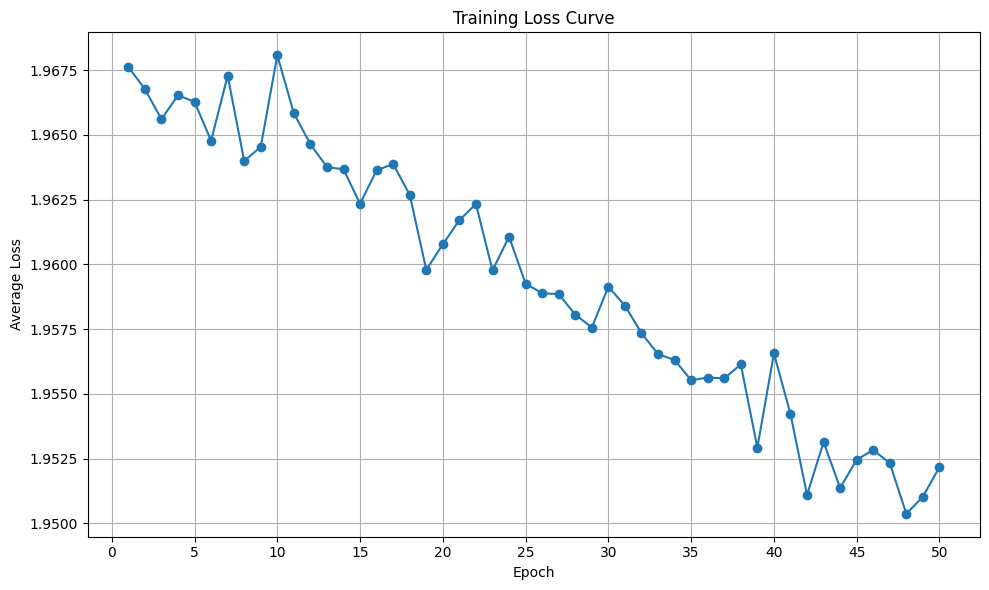

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs_real + 1), history_loss, marker='o', linestyle='-')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.xticks(range(0, num_epochs_real + 1, 5)) # Show ticks every 5 epochs
plt.tight_layout()
plt.show()

### Testing with Simulated Saturn Data

Following the pattern for Jupiter and Earth, we will now simulate data for Saturn and make a prediction using the trained model.

In [27]:
# --- Simulate Saturn's Data ---
# In a real application, you would load actual Saturn data.

# Create a unique graph Laplacian for Saturn
saturn_L_scaled = create_synthetic_spherical_graph(num_nodes=num_nodes)

# Create a unique signal for Saturn
# Assuming in_channels and num_nodes are consistent with training
saturn_signal = torch.randn(1, num_nodes, in_channels) # Batch size of 1 for a single planet

print(f"Saturn Signal Shape: {saturn_signal.shape}")
print(f"Saturn L_scaled Shape: {saturn_L_scaled.shape}")

Saturn Signal Shape: torch.Size([1, 500, 3])
Saturn L_scaled Shape: torch.Size([500, 500])


In [28]:
# --- Make a prediction for Saturn ---

# Set the model to evaluation mode
model_planet_real.eval()

with torch.no_grad(): # Disable gradient calculations for inference
    saturn_output = model_planet_real(saturn_signal, [saturn_L_scaled]) # Pass L_scaled as a list

# Get the predicted class (assuming it's a classification task)
predicted_class_saturn = torch.argmax(saturn_output, dim=1).item()

print(f"Model output for Saturn: {saturn_output}")
print(f"Predicted class for Saturn: {predicted_class_saturn}")

Model output for Saturn: tensor([[ 0.7435,  0.3733,  0.7201,  0.7570, -4.6633,  0.2938, -0.4498, -0.4393,
          1.3101, -4.8090]])
Predicted class for Saturn: 8
